In [5]:
import pandas as pd
import os

def main():
    target_dms_ids = [
        "AICDA_HUMAN_Gajula_2014_3cycles",
        "AMIE_PSEAE_Wrenbeck_2017",
        "CAS9_STRP1_Spencer_2017_positive",
        "LGK_LIPST_Klesmith_2015",
        "OTC_HUMAN_Lo_2023",
        "PTEN_HUMAN_Mighell_2018",
        "RASH_HUMAN_Bandaru_2017",
        "RNC_ECOLI_Weeks_2023",
        "VKOR1_HUMAN_Chiasson_2020_activity"
    ]

    input_csv = "/share/home/wangtb/enzyme_shells_backup/olig_activity/raw_data/ProteinGym/benchmarks/DMS_zero_shot/substitutions/Spearman/DMS_substitutions_Spearman_DMS_level.csv"
    output_dir = "/share/home/wangtb/enzyme_shells/analysis"
    output_csv = os.path.join(output_dir, "benchmark.csv")

    os.makedirs(output_dir, exist_ok=True)

    print(f"正在读取官方 Benchmark 文件:\n{input_csv}")
    
    try:
        df_all = pd.read_csv(input_csv)
        
        df_filtered = df_all[df_all['DMS ID'].isin(target_dms_ids)]
        
        df_filtered.to_csv(output_csv, index=False)
        print("-" * 30)
        print(f"✅ 成功提取了 {len(df_filtered)} 个数据集的基线表现。")
        print(f"📁 文件已保存至:\n{output_csv}")
        
        found_ids = df_filtered['DMS ID'].tolist()
        missing_ids = set(target_dms_ids) - set(found_ids)
        if missing_ids:
            print("\n⚠️ 警告：以下数据集在官方 benchmark 文件中未找到，请检查名称是否拼写正确：")
            for missing in missing_ids:
                print(f" - {missing}")
                
    except FileNotFoundError:
        print(f"❌ 错误：找不到输入文件。请检查 {input_csv} 是否存在。")
    except KeyError:
        print("❌ 错误：输入文件中找不到 'DMS ID' 这一列，请检查文件格式。")
    except Exception as e:
        print(f"❌ 发生未知错误: {e}")

if __name__ == "__main__":
    main()

正在读取官方 Benchmark 文件:
/share/home/wangtb/enzyme_shells_backup/olig_activity/raw_data/ProteinGym/benchmarks/DMS_zero_shot/substitutions/Spearman/DMS_substitutions_Spearman_DMS_level.csv
------------------------------
✅ 成功提取了 9 个数据集的基线表现。
📁 文件已保存至:
/share/home/wangtb/enzyme_shells/analysis/benchmark.csv


In [6]:
# 读取 benchmark 文件
df = pd.read_csv("/share/home/wangtb/enzyme_shells/analysis/benchmark.csv")
# 对于第一列DMS ID，以_进行分割，提取第一个元素作为新的列DMS_ID
df['DMS ID'] = df['DMS ID'].apply(lambda x: x.split('_')[0])
# 保存新的CSV文件
output_csv = "/share/home/wangtb/enzyme_shells/analysis/benchmark.csv"
print(f"正在保存新的 benchmark 文件:\n{output_csv}")
df.to_csv(output_csv, index=False)
print(f"✅ 成功更新了 benchmark 文件，新的 'DMS ID' 列已保存至:\n{output_csv}")


正在保存新的 benchmark 文件:
/share/home/wangtb/enzyme_shells/analysis/benchmark.csv
✅ 成功更新了 benchmark 文件，新的 'DMS ID' 列已保存至:
/share/home/wangtb/enzyme_shells/analysis/benchmark.csv


In [3]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from scipy.optimize import least_squares
from scipy.stats import spearmanr
import warnings
import random

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
seed_everything(42)

warnings.filterwarnings('ignore')

DATA_DIR = "/share/home/wangtb/enzyme_shells/activity_data"
ANALYSIS_DIR = "/share/home/wangtb/enzyme_shells/analysis"
BENCHMARK_FILE = os.path.join(ANALYSIS_DIR, "benchmark.csv")
OUT_FILE = os.path.join(ANALYSIS_DIR, "benchmark.csv")

if not os.path.exists(ANALYSIS_DIR):
    os.makedirs(ANALYSIS_DIR)

SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']

def get_ec_number(filename):
    filename_upper = filename.upper()
    ec_rules = {
        'AICDA': 3, 'AMIE': 3, 'CAS9': 3, 'PTEN': 3, 'RASH': 3, 
        'RNC': 3, 'PAFA': 3, 'LGK': 2, 'OTC': 2, 'SRC': 2, 
        'VKOR1': 1, 'RUBISCO': 4, '2024_01_30': 4
    }
    for keyword, ec_val in ec_rules.items():
        if keyword in filename_upper:
            return ec_val
    return 3

def get_raw_target_col(filename):
    filename_upper = filename.upper()
    if 'RUBISCO' in filename_upper:
        return 'Km_mean'
    elif 'PAFA' in filename_upper:
        return 'kcat'
    elif 'PTEN' in filename_upper:
        if '2018' in filename_upper:
            return 'DMS_score'
        else:
            return 'Cum_score'
    else:
        return 'DMS_score'

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

def predict_score(P, d, X):
    X_mpnn = X[:, 0]
    X_dca  = X[:, 1]
    X_foldx= X[:, 2]
    y_pred = P[0] * X_mpnn + P[1] * X_dca + P[2] * X_foldx + P[3] * d + P[4]
    return y_pred

def objective_function(P, d, X, y_true):
    y_pred = predict_score(P, d, X)
    return y_pred - y_true

# P0 包含 5 个参数：[w_mpnn, w_dca, w_foldx, w_d, b]
P0 = np.array([-0.5, 0.5, 0.1, 0.0, 0.0])

print(f"正在读取 Benchmark 文件: {BENCHMARK_FILE}")
benchmark_df = pd.read_csv(BENCHMARK_FILE)

print(f"正在读取 {DATA_DIR} 下的CSV文件...")
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

datasets = {}
for file_path in csv_files:
    file_name = os.path.basename(file_path)
    raw_target = get_raw_target_col(file_name)
    
    try:
        df = pd.read_csv(file_path)
        cols_to_check = SCORES + ['Distance_to_Active_Site', raw_target]
        
        missing_cols = [c for c in cols_to_check if c not in df.columns]
        if missing_cols:
            continue
            
        df = df.dropna(subset=cols_to_check)
        df = filter_single_mutations(df)
        
        for col in cols_to_check:
            df[col] = df[col].astype(float)
        
        final_target = raw_target
        
        if 'PAFA' in file_name.upper():
            df = df[df['kcat'] > 0].copy()
            df['lg_kcat'] = np.log10(df['kcat'])
            final_target = 'lg_kcat'
        elif 'RUBISCO' in file_name.upper() or '2024_01_30' in file_name.upper():
            df = df[df['Km_mean'] > 0].copy()
            df['neg_lg_Km'] = -np.log10(df['Km_mean'])
            final_target = 'neg_lg_Km'
            
        if len(df) > 0:
            df['unified_target'] = df[final_target]
            datasets[file_name] = {'data': df, 'target': final_target, 'ec': get_ec_number(file_name)}
            print(f"成功加载: {file_name:.<40} 样本数: {len(df)}")
    except Exception as e:
        print(f"读取文件 {file_name} 时发生错误: {e}")


print("\n开始执行跨目标蛋白泛化测试 (Zero-shot Transfer)...")
our_model_scores = []

for dms_id in benchmark_df['DMS_id']:
    test_filename = f"{dms_id}.csv"
    
    train_dfs = []
    for f_name, info in datasets.items():
        if f_name == test_filename:
            continue
        
        if "PTEN" in f_name.upper() and "2018" not in f_name.upper():
            continue
            
        train_dfs.append(info['data'])
        
    if not train_dfs:
        print(f"[{dms_id}] 没有找到有效的训练数据！")
        our_model_scores.append(np.nan)
        continue
        
    df_train_agg = pd.concat(train_dfs, ignore_index=True)
    
    qt_X = QuantileTransformer(output_distribution='normal', random_state=42)
    X_train = qt_X.fit_transform(df_train_agg[SCORES])
    d_train = df_train_agg['Distance_to_Active_Site'].values
    
    qt_y_train = QuantileTransformer(output_distribution='normal', random_state=42)
    y_train = qt_y_train.fit_transform(df_train_agg[['unified_target']]).ravel()
    
    result = least_squares(objective_function, P0, args=(d_train, X_train, y_train), loss='soft_l1')
    P_opt = result.x
    
    if test_filename in datasets:
        df_test = datasets[test_filename]['data']
        
        X_test = qt_X.transform(df_test[SCORES])
        d_test = df_test['Distance_to_Active_Site'].values
        
        qt_y_test = QuantileTransformer(output_distribution='normal', random_state=42)
        y_test_true = qt_y_test.fit_transform(df_test[['unified_target']]).ravel()
        
        y_pred_test = predict_score(P_opt, d_test, X_test)
        r_test, _ = spearmanr(y_test_true, y_pred_test)
        
        our_model_scores.append(r_test)
        print(f"✅ {dms_id:.<40} Spearman R: {r_test:.4f}")
    else:
        print(f"❌ 警告: 在数据目录中未找到测试集 {test_filename}")
        our_model_scores.append(np.nan)


if 'Our_Model_1' in benchmark_df.columns:
    benchmark_df = benchmark_df.drop(columns=['Our_Model_1'])

dms_id_idx = benchmark_df.columns.get_loc('DMS_id')
benchmark_df.insert(dms_id_idx + 1, 'Our_Model_1', our_model_scores)

benchmark_df.to_csv(OUT_FILE, index=False)
print("-" * 50)
print(f"评估完成！模型表现已成功写入: {OUT_FILE}")

正在读取 Benchmark 文件: /share/home/wangtb/enzyme_shells/analysis/benchmark.csv
正在读取 /share/home/wangtb/enzyme_shells/activity_data 下的CSV文件...
成功加载: PTEN.csv................................ 样本数: 7260
成功加载: PAFA.csv................................ 样本数: 1016
成功加载: AICDA.csv............................... 样本数: 209
成功加载: AMIE.csv................................ 样本数: 6227
成功加载: CAS9.csv................................ 样本数: 8117
成功加载: LGK.csv................................. 样本数: 7890
成功加载: OTC.csv................................. 样本数: 1570
成功加载: PTEN_2018.csv........................... 样本数: 7260
成功加载: RASH.csv................................ 样本数: 3134
成功加载: RNC.csv................................. 样本数: 4277
成功加载: RUBISCO.csv............................. 样本数: 8550
成功加载: VKOR1.csv............................... 样本数: 697

开始执行跨目标蛋白泛化测试 (Zero-shot Transfer)...
✅ AICDA................................... Spearman R: 0.3983
✅ AMIE.................................... Spearman R: 0.5784
✅ CAS9...........

In [4]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from scipy.optimize import least_squares
from scipy.stats import spearmanr
import warnings
import random

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
seed_everything(42)

warnings.filterwarnings('ignore')

DATA_DIR = "/share/home/wangtb/enzyme_shells/activity_data"
ANALYSIS_DIR = "/share/home/wangtb/enzyme_shells/analysis"
BENCHMARK_FILE = os.path.join(ANALYSIS_DIR, "benchmark.csv")
OUT_FILE = os.path.join(ANALYSIS_DIR, "benchmark.csv")

if not os.path.exists(ANALYSIS_DIR):
    os.makedirs(ANALYSIS_DIR)

SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']

def get_ec_number(filename):
    filename_upper = filename.upper()
    ec_rules = {
        'AICDA': 3, 'AMIE': 3, 'CAS9': 3, 'PTEN': 3, 'RASH': 3, 
        'RNC': 3, 'PAFA': 3, 'LGK': 2, 'OTC': 2, 'SRC': 2, 
        'VKOR1': 1, 'RUBISCO': 4, '2024_01_30': 4
    }
    for keyword, ec_val in ec_rules.items():
        if keyword in filename_upper:
            return ec_val
    return 3

def get_raw_target_col(filename):
    filename_upper = filename.upper()
    if 'RUBISCO' in filename_upper:
        return 'Km_mean'
    elif 'PAFA' in filename_upper:
        return 'kcat'
    elif 'PTEN' in filename_upper:
        if '2018' in filename_upper:
            return 'DMS_score'
        else:
            return 'Cum_score'
    else:
        return 'DMS_score'

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

def predict_score(P, d, X):
    X_mpnn = X[:, 0]
    X_dca  = X[:, 1]
    X_foldx= X[:, 2]
    
    safe_d = (d * np.abs(P[4])) + 1
    
    y_pred = P[0] * (X_mpnn / safe_d) + P[1] * (X_dca / safe_d) + P[2] * (X_foldx / safe_d) + P[3]
    return y_pred

def objective_function(P, d, X, y_true):
    y_pred = predict_score(P, d, X)
    return y_pred - y_true

P0 = np.array([-0.5, 0.5, 0.1, 0.0, 0.1])

print(f"正在读取 Benchmark 文件: {BENCHMARK_FILE}")
benchmark_df = pd.read_csv(BENCHMARK_FILE)

print(f"正在读取 {DATA_DIR} 下的CSV文件...")
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

datasets = {}
for file_path in csv_files:
    file_name = os.path.basename(file_path)
    raw_target = get_raw_target_col(file_name)
    
    try:
        df = pd.read_csv(file_path)
        cols_to_check = SCORES + ['Distance_to_Active_Site', raw_target]
        
        missing_cols = [c for c in cols_to_check if c not in df.columns]
        if missing_cols:
            continue
            
        df = df.dropna(subset=cols_to_check)
        df = filter_single_mutations(df)
        
        for col in cols_to_check:
            df[col] = df[col].astype(float)
        
        final_target = raw_target
        
        if 'PAFA' in file_name.upper():
            df = df[df['kcat'] > 0].copy()
            df['lg_kcat'] = np.log10(df['kcat'])
            final_target = 'lg_kcat'
        elif 'RUBISCO' in file_name.upper() or '2024_01_30' in file_name.upper():
            df = df[df['Km_mean'] > 0].copy()
            df['neg_lg_Km'] = -np.log10(df['Km_mean'])
            final_target = 'neg_lg_Km'
            
        if len(df) > 0:
            df['unified_target'] = df[final_target]
            datasets[file_name] = {'data': df, 'target': final_target, 'ec': get_ec_number(file_name)}
            print(f"成功加载: {file_name:.<40} 样本数: {len(df)}")
    except Exception as e:
        print(f"读取文件 {file_name} 时发生错误: {e}")


print("\n开始执行跨目标蛋白泛化测试 (Zero-shot Transfer)...")
our_model_scores = []

for dms_id in benchmark_df['DMS_id']:
    test_filename = f"{dms_id}.csv"
    
    train_dfs = []
    for f_name, info in datasets.items():
        if f_name == test_filename:
            continue
        
        if "PTEN" in f_name.upper() and "2018" not in f_name.upper():
            continue
            
        train_dfs.append(info['data'])
        
    if not train_dfs:
        print(f"[{dms_id}] 没有找到有效的训练数据！")
        our_model_scores.append(np.nan)
        continue
        
    df_train_agg = pd.concat(train_dfs, ignore_index=True)
    
    qt_X = QuantileTransformer(output_distribution='normal', random_state=42)
    X_train = qt_X.fit_transform(df_train_agg[SCORES])
    d_train = df_train_agg['Distance_to_Active_Site'].values
    
    qt_y_train = QuantileTransformer(output_distribution='normal', random_state=42)
    y_train = qt_y_train.fit_transform(df_train_agg[['unified_target']]).ravel()
    
    result = least_squares(objective_function, P0, args=(d_train, X_train, y_train), loss='soft_l1')
    P_opt = result.x
    
    if test_filename in datasets:
        df_test = datasets[test_filename]['data']
        
        X_test = qt_X.transform(df_test[SCORES])
        d_test = df_test['Distance_to_Active_Site'].values
        
        qt_y_test = QuantileTransformer(output_distribution='normal', random_state=42)
        y_test_true = qt_y_test.fit_transform(df_test[['unified_target']]).ravel()
        
        y_pred_test = predict_score(P_opt, d_test, X_test)
        r_test, _ = spearmanr(y_test_true, y_pred_test)
        
        our_model_scores.append(r_test)
        print(f"✅ {dms_id:.<40} Spearman R: {r_test:.4f}")
    else:
        print(f"❌ 警告: 在数据目录中未找到测试集 {test_filename}")
        our_model_scores.append(np.nan)


if 'Our_Model_2' in benchmark_df.columns:
    benchmark_df = benchmark_df.drop(columns=['Our_Model_2'])

dms_id_idx = benchmark_df.columns.get_loc('DMS_id')
benchmark_df.insert(dms_id_idx + 2, 'Our_Model_2', our_model_scores)

benchmark_df.to_csv(OUT_FILE, index=False)
print("-" * 50)
print(f"评估完成！模型表现已成功写入: {OUT_FILE}")

正在读取 Benchmark 文件: /share/home/wangtb/enzyme_shells/analysis/benchmark.csv
正在读取 /share/home/wangtb/enzyme_shells/activity_data 下的CSV文件...
成功加载: PTEN.csv................................ 样本数: 7260
成功加载: PAFA.csv................................ 样本数: 1016
成功加载: AICDA.csv............................... 样本数: 209
成功加载: AMIE.csv................................ 样本数: 6227
成功加载: CAS9.csv................................ 样本数: 8117
成功加载: LGK.csv................................. 样本数: 7890
成功加载: OTC.csv................................. 样本数: 1570
成功加载: PTEN_2018.csv........................... 样本数: 7260
成功加载: RASH.csv................................ 样本数: 3134
成功加载: RNC.csv................................. 样本数: 4277
成功加载: RUBISCO.csv............................. 样本数: 8550
成功加载: VKOR1.csv............................... 样本数: 697

开始执行跨目标蛋白泛化测试 (Zero-shot Transfer)...
✅ AICDA................................... Spearman R: 0.3812
✅ AMIE.................................... Spearman R: 0.5610
✅ CAS9...........

正在读取文件: /share/home/wangtb/enzyme_shells/analysis/benchmark.csv


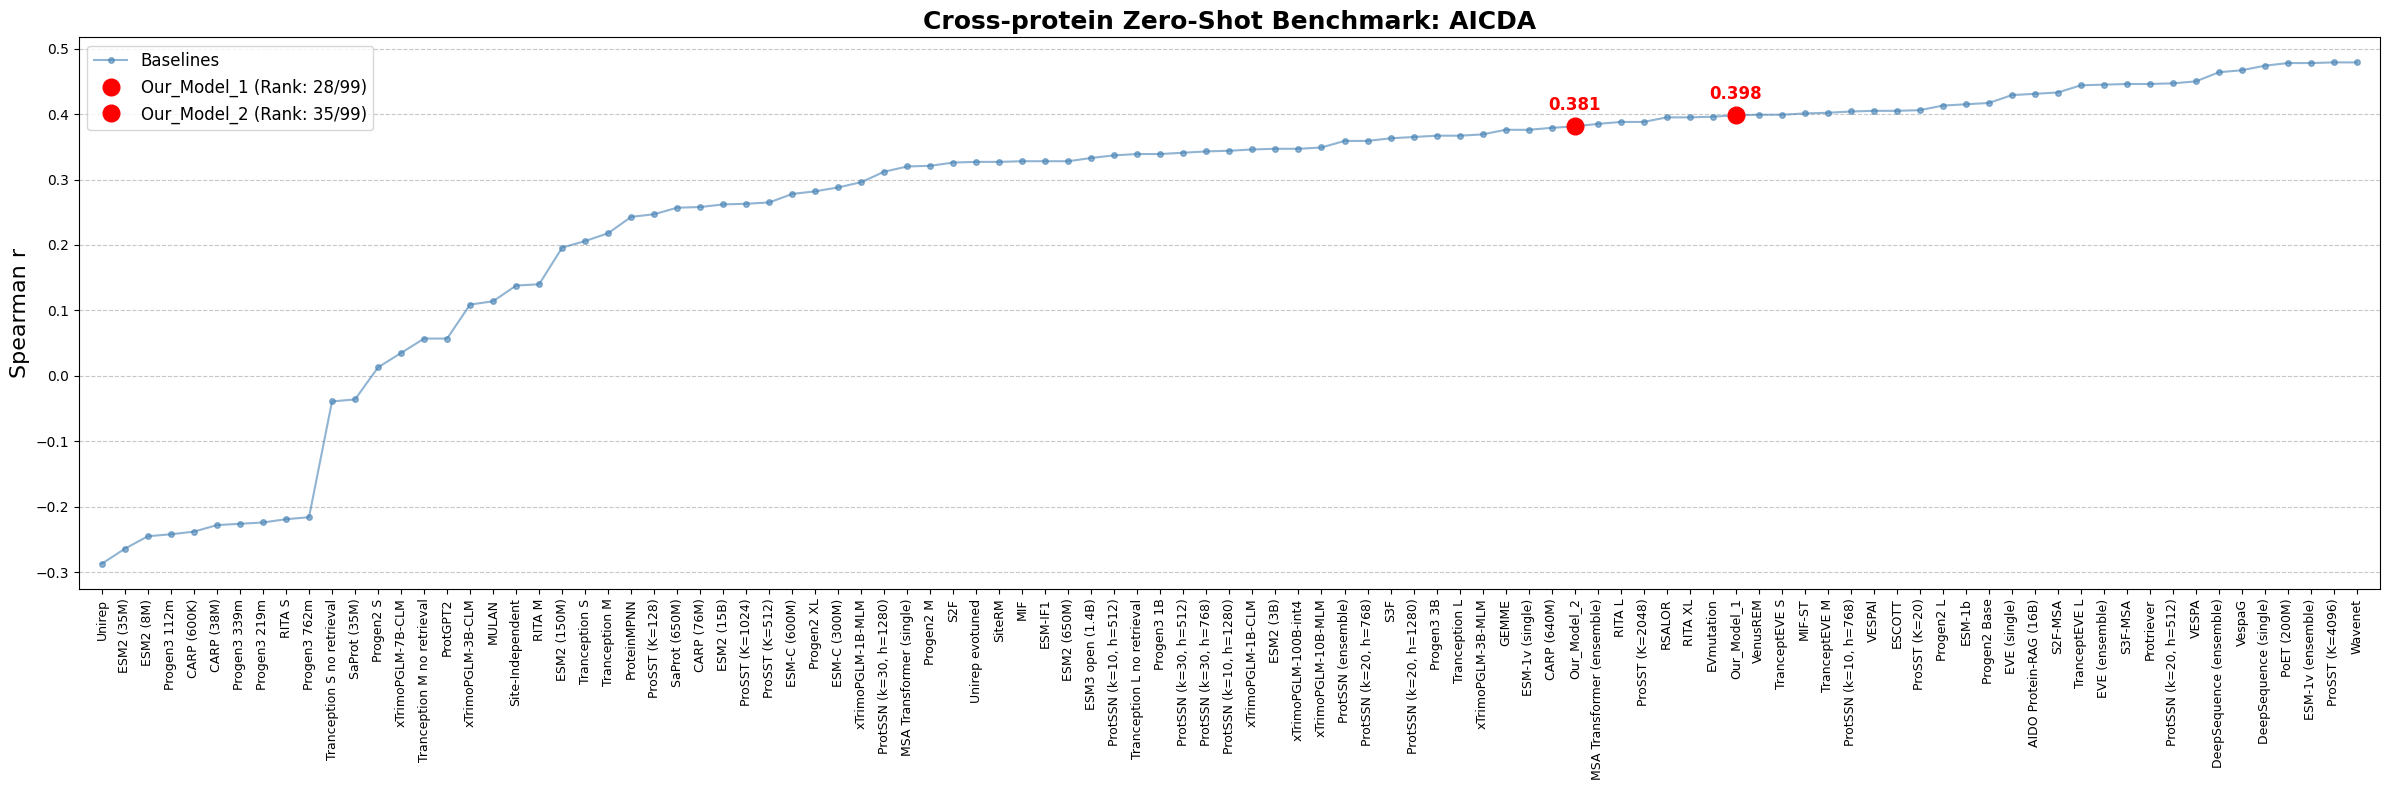

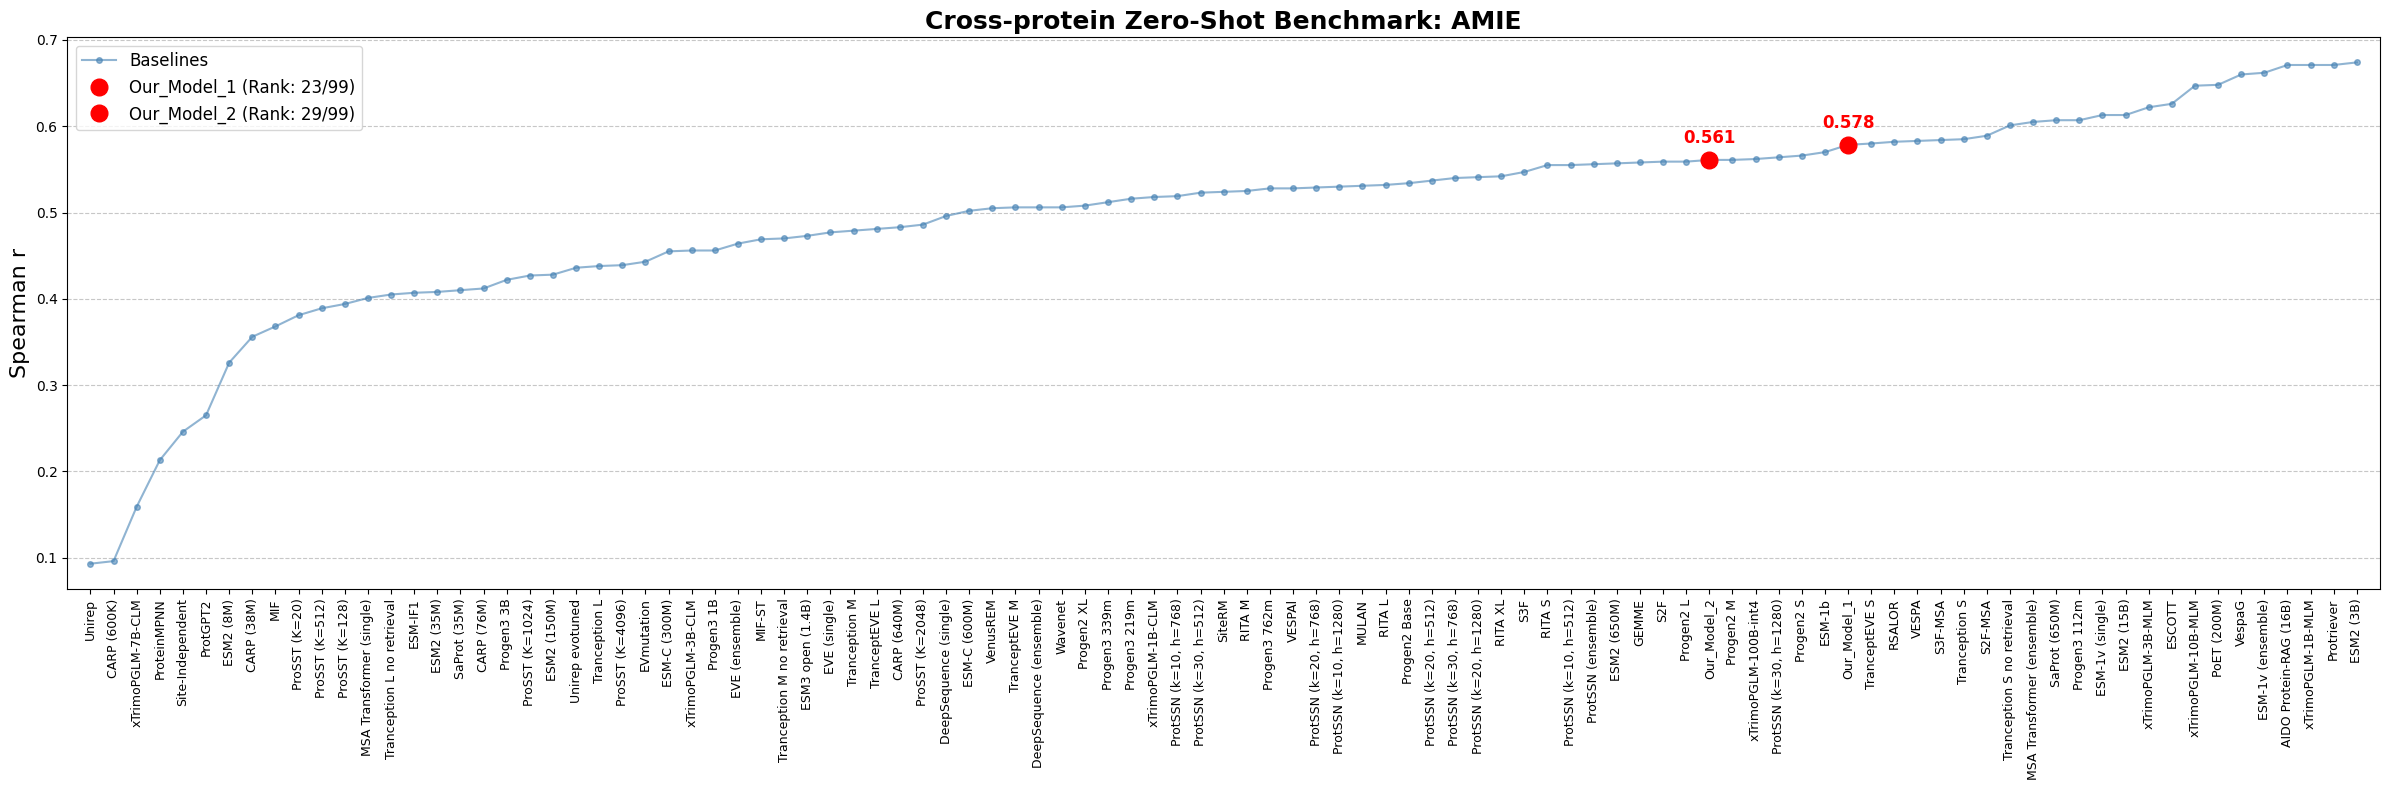

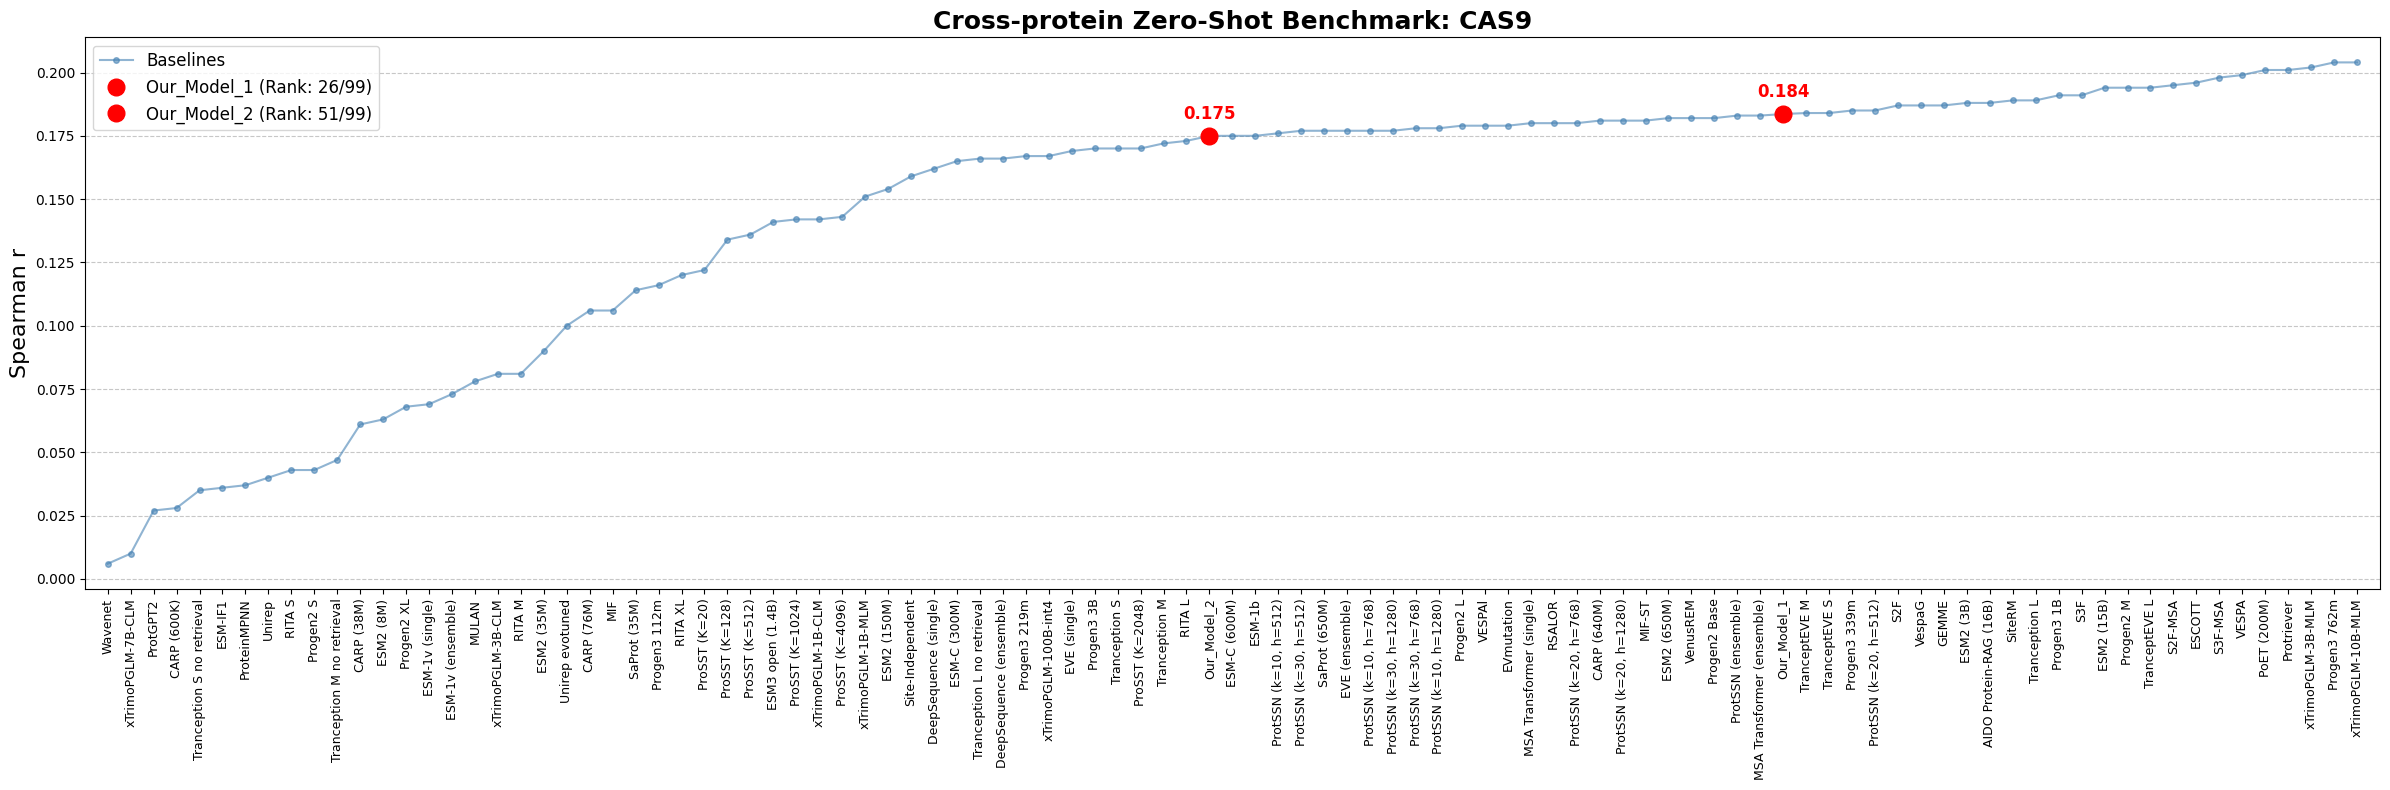

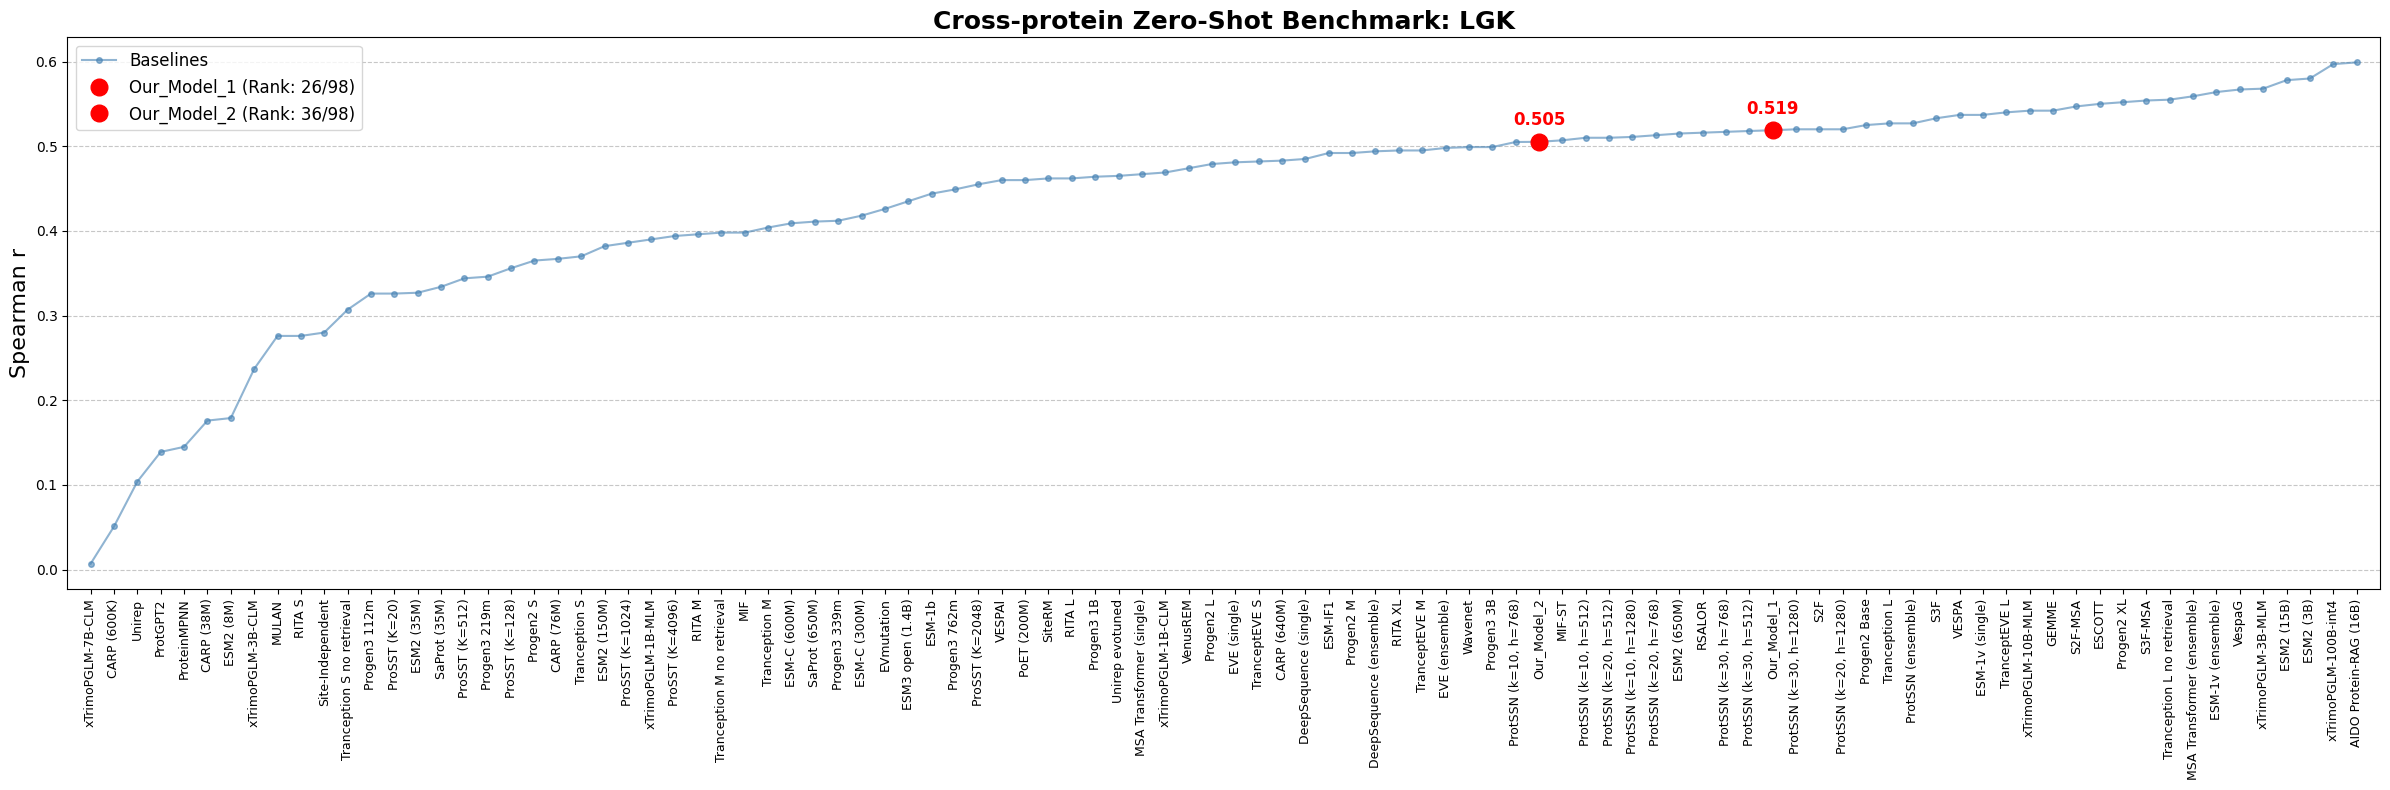

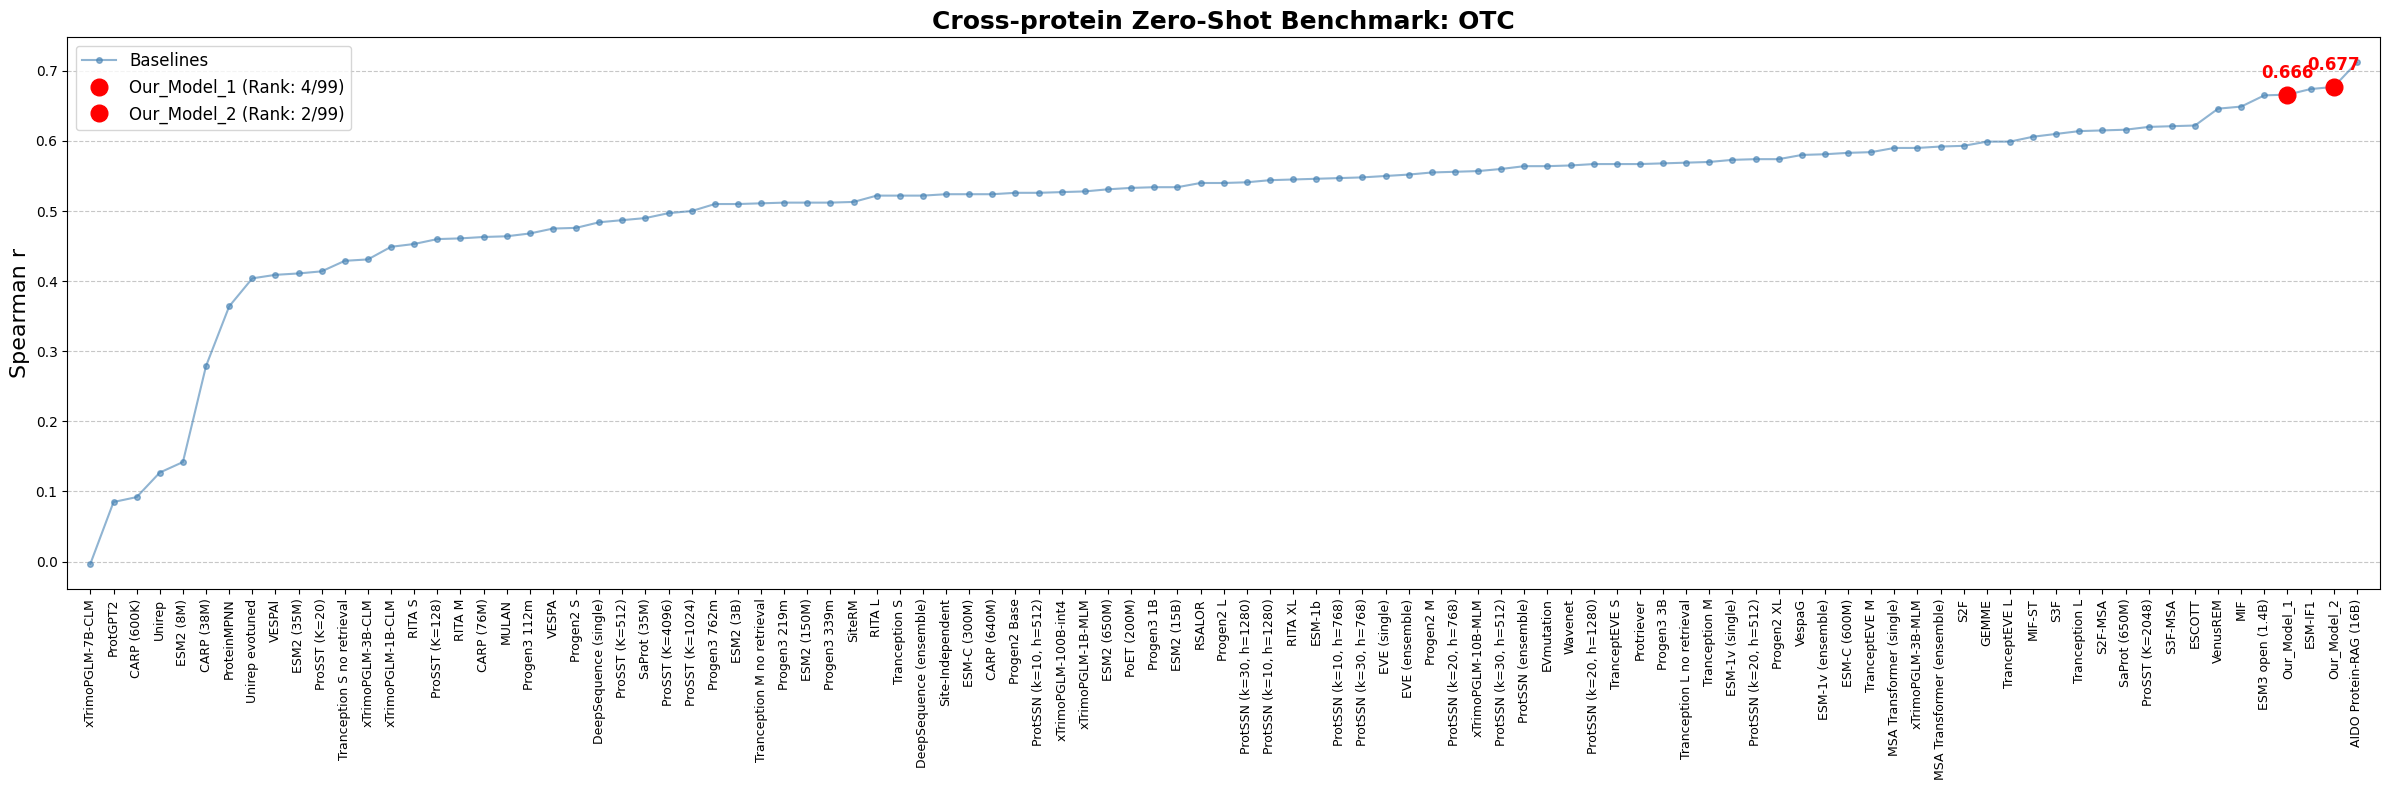

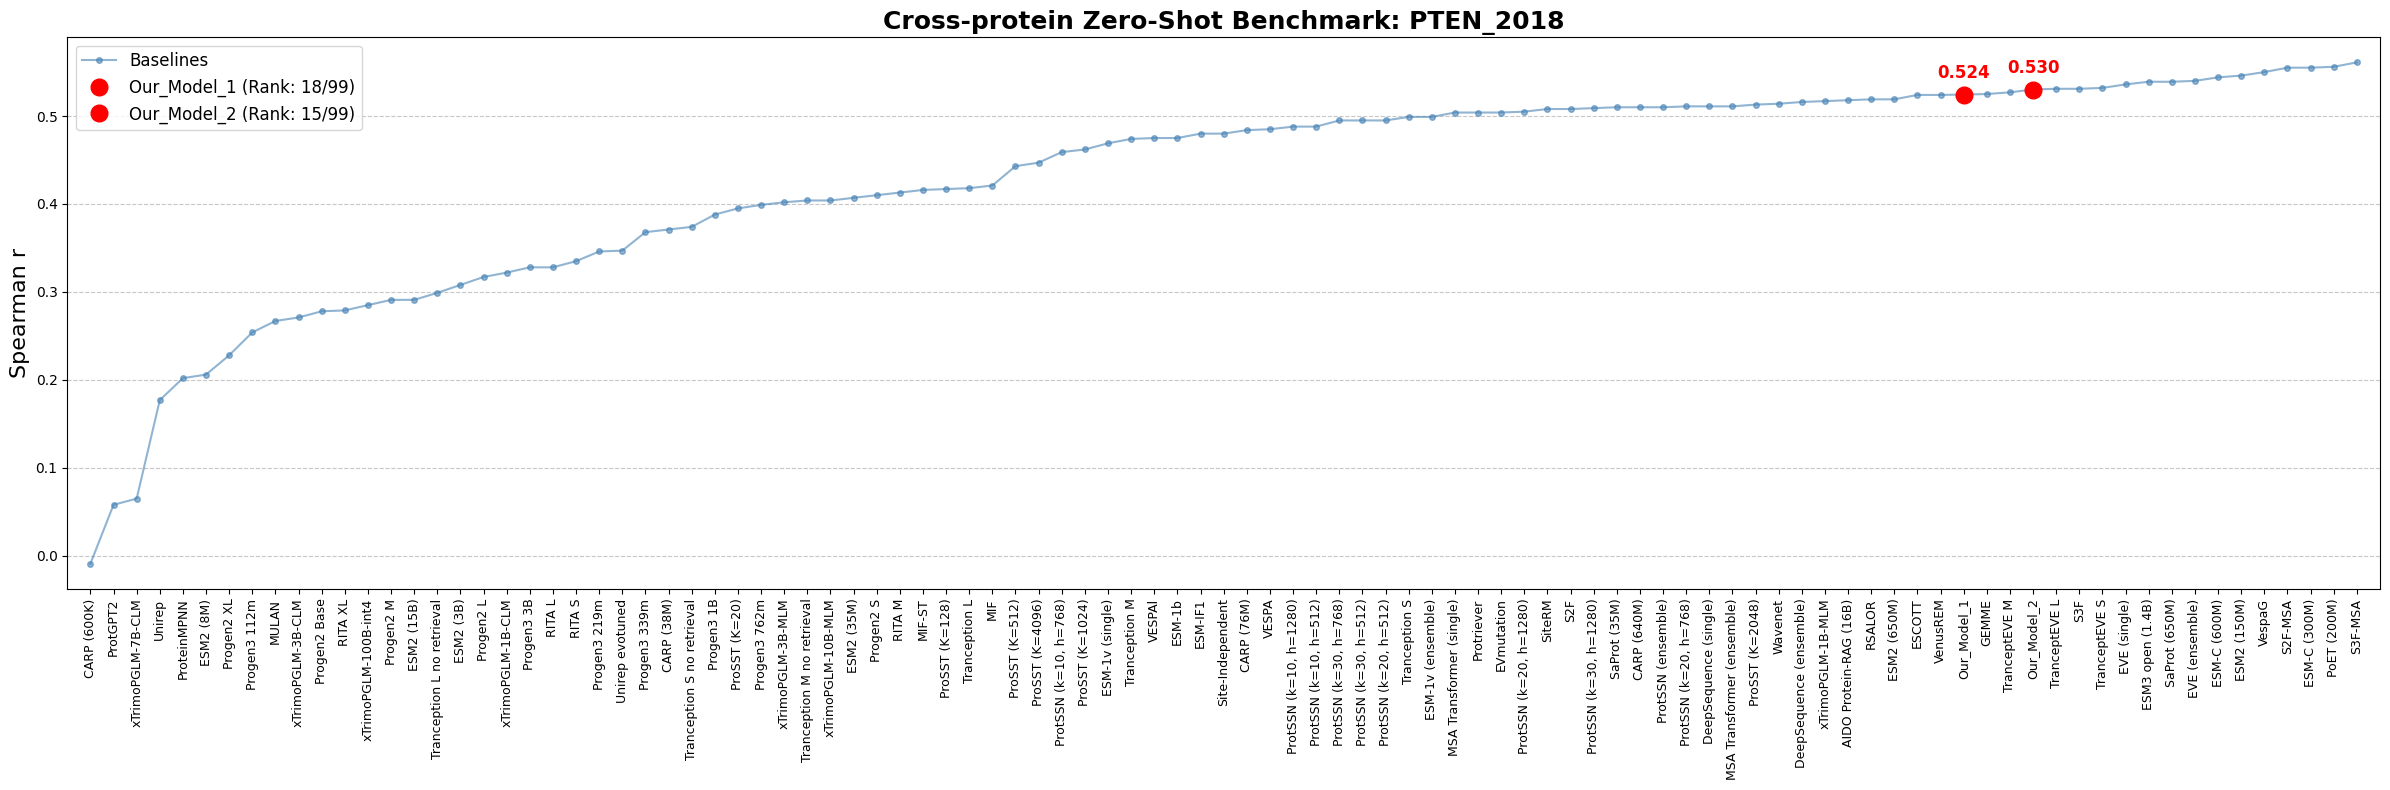

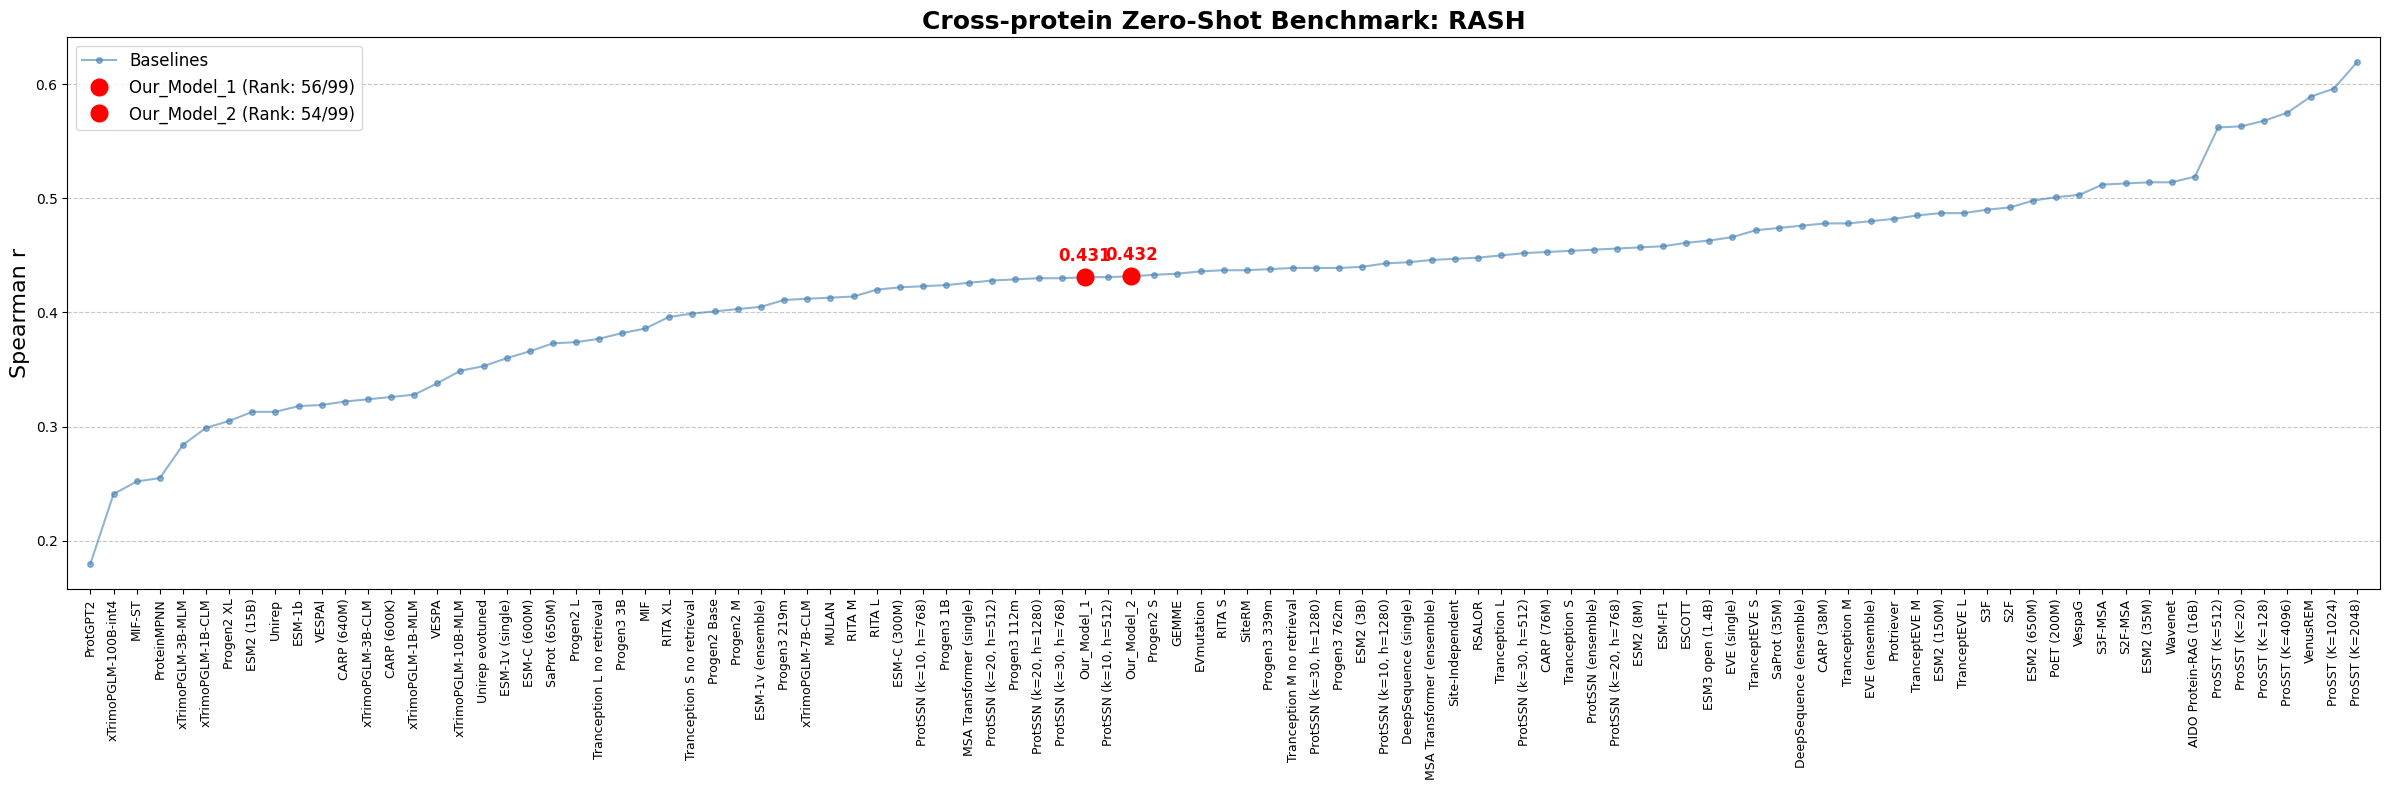

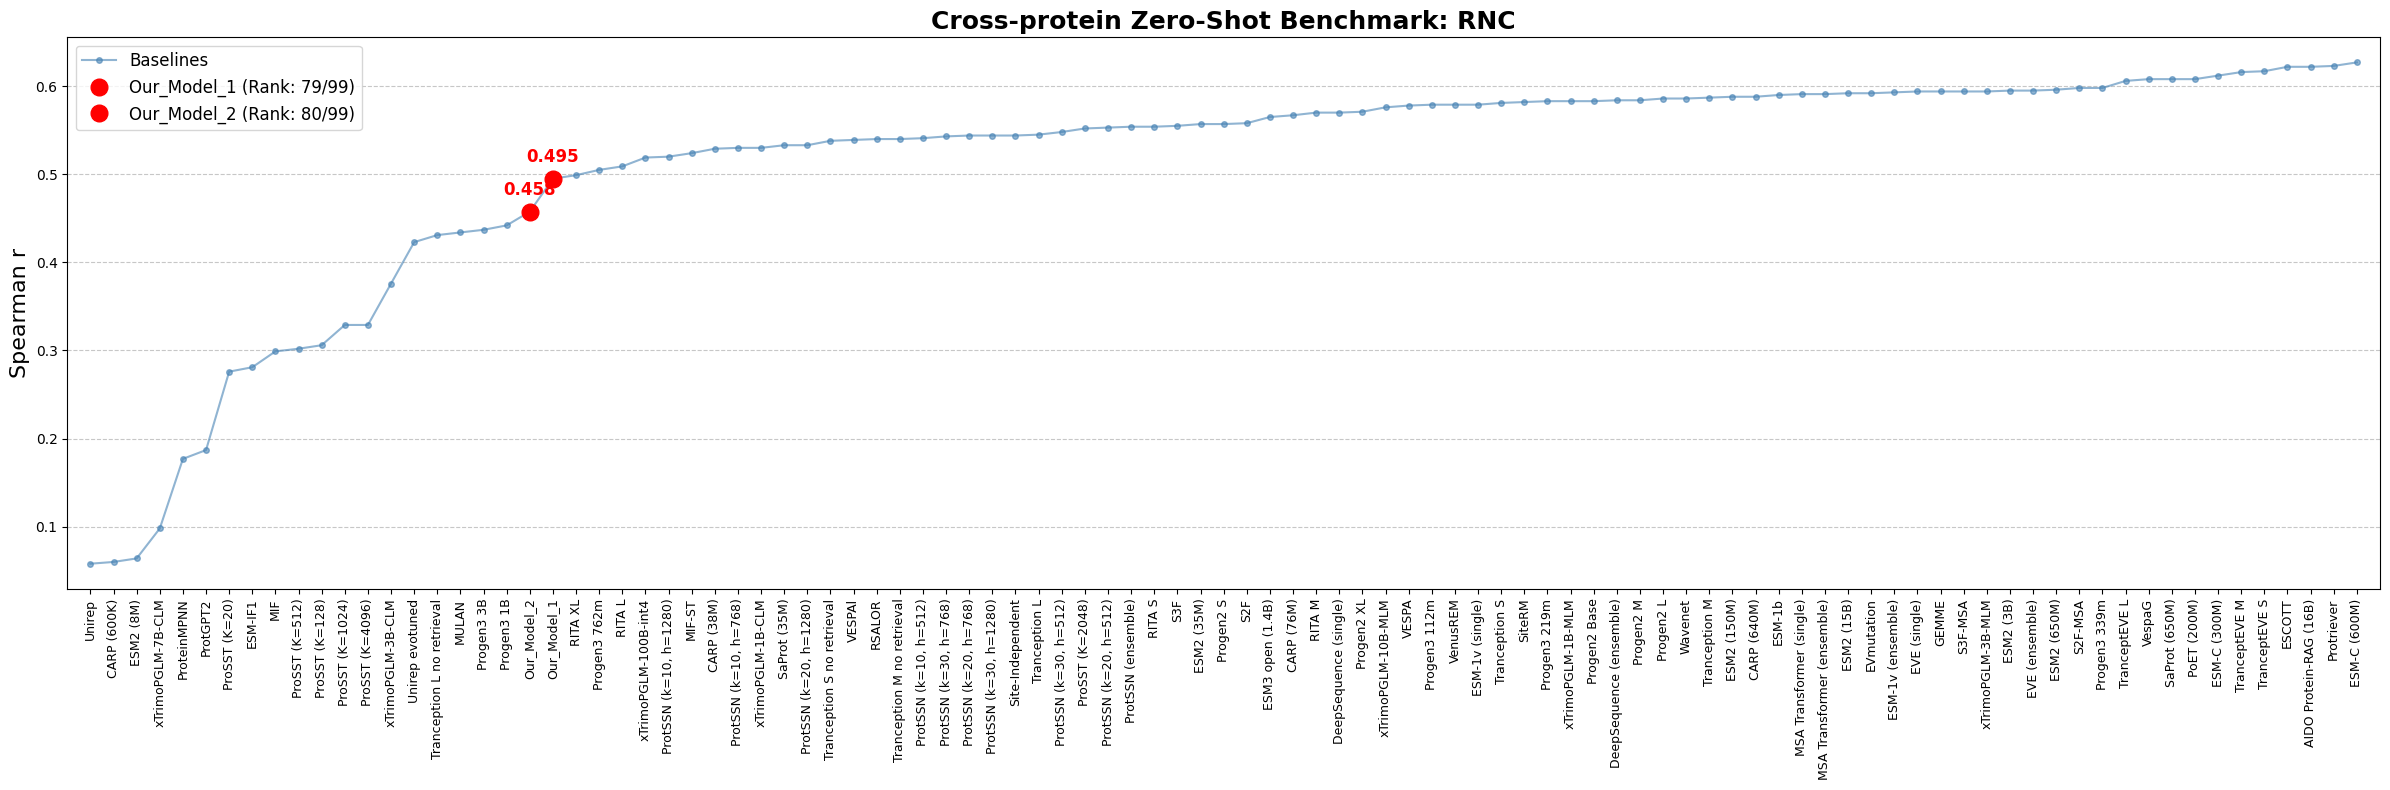

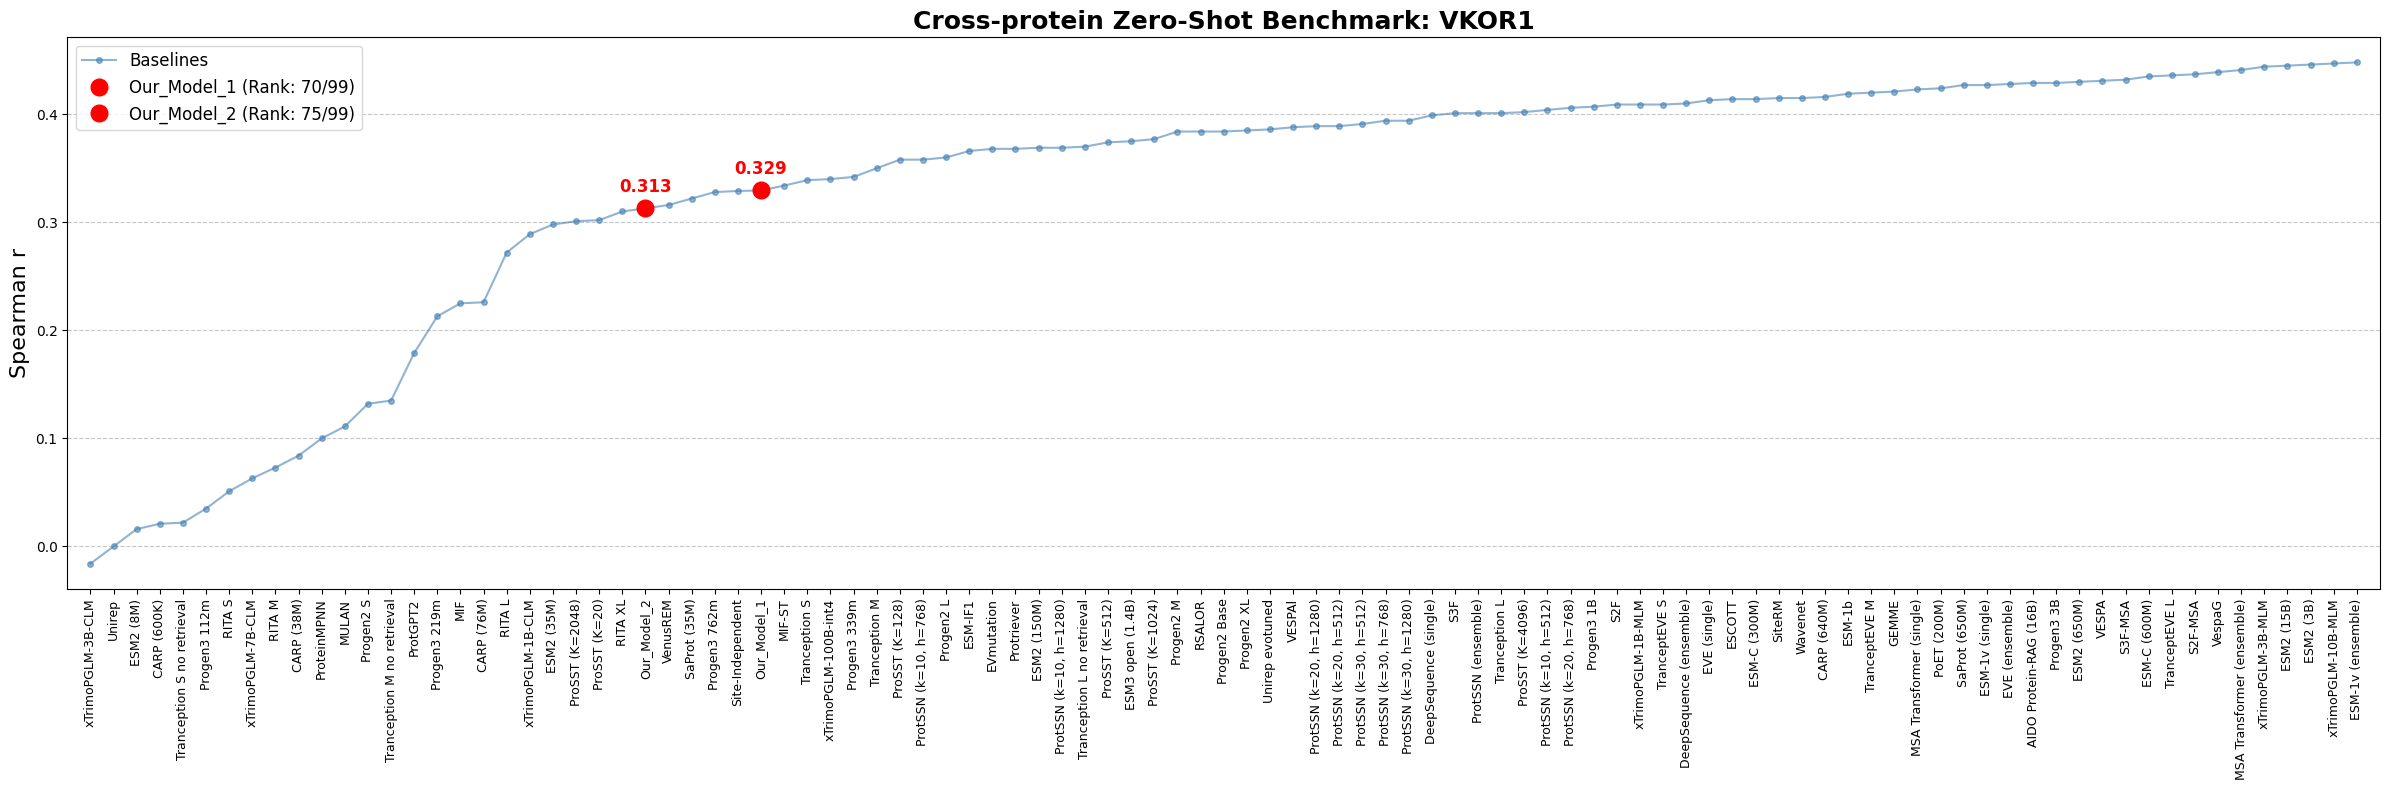

🎉 所有 Benchmark 可视化图表已完成！


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

INPUT_CSV = "/share/home/wangtb/enzyme_shells/analysis/benchmark.csv"
OUTPUT_DIR = "/share/home/wangtb/enzyme_shells/analysis/plots"

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print(f"正在读取文件: {INPUT_CSV}")
df = pd.read_csv(INPUT_CSV)

meta_cols = ['DMS_id', 'Number of Mutants', 'Selection Type', 'UniProt ID', 'MSA_Neff_L_category', 'Taxon']
model_cols = [c for c in df.columns if c not in meta_cols]

for idx, row in df.iterrows():
    dms_id = row['DMS_id']
    
    scores = row[model_cols]
    
    scores = scores.dropna()
    scores = scores.astype(float)
    
    scores_sorted = scores.sort_values()
    
    models_sorted = scores_sorted.index.tolist()
    vals_sorted = scores_sorted.values.tolist()
    
    plt.figure(figsize=(24, 8))
    x_positions = np.arange(len(models_sorted))
    
    plt.plot(x_positions, vals_sorted, marker='o', markersize=4, linestyle='-', color='steelblue', alpha=0.6, label='Baselines')
    
    for o_model in ['Our_Model_1', 'Our_Model_2']:
        if o_model in models_sorted:
            m_idx = models_sorted.index(o_model)
            rank = len(models_sorted) - m_idx
            
            plt.plot(m_idx, vals_sorted[m_idx], marker='o', color='red', markersize=12, 
                     linestyle='None', label=f'{o_model} (Rank: {rank}/{len(models_sorted)})')
            
            plt.annotate(f'{vals_sorted[m_idx]:.3f}', 
                         (m_idx, vals_sorted[m_idx]), 
                         textcoords="offset points", 
                         xytext=(0, 12), 
                         ha='center', 
                         color='red',
                         fontweight='bold',
                         fontsize=12)

    plt.title(f'Cross-protein Zero-Shot Benchmark: {dms_id}', fontsize=18, fontweight='bold')
    plt.ylabel('Spearman r', fontsize=16)
    
    plt.xticks(x_positions, models_sorted, rotation=90, fontsize=9)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=12)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xlim(-1, len(models_sorted))
    
    plt.tight_layout()
    plt.show()

print("🎉 所有 Benchmark 可视化图表已完成！")